In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator

# Load your unsorted data
data = np.loadtxt('test1.txt')
x = data[:, 0]
y = data[:, 1]
z = data[:, 2]
w = data[:, 3]

# Combine coordinates into points array
points = np.column_stack((x, y, z))

# Create the interpolator for scattered data
interpolator = LinearNDInterpolator(points, w)

# Define the regular grid bounds (min to max of your data)
offset = 0.2
x_min, x_max = x.min() + offset, x.max() - offset
y_min, y_max = y.min() + offset, y.max() - offset
z_min, z_max = z.min() + offset, z.max() - offset

# Create a 20x20x20 regular grid
grid_size = 50
x_regular = np.linspace(x_min, x_max, grid_size)
y_regular = np.linspace(y_min, y_max, grid_size)
z_regular = np.linspace(z_min, z_max, grid_size)

# Create meshgrid for the regular grid
X, Y, Z = np.meshgrid(x_regular, y_regular, z_regular, indexing='ij')

# Flatten the grid points for interpolation
grid_points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))

# Interpolate weights onto the regular grid
w_regular_flat = interpolator(grid_points)

# Reshape back to 3D grid
w_regular = w_regular_flat.reshape(grid_size, grid_size, grid_size)

# Optional: Handle NaN values (points outside convex hull)
# You can replace NaN with 0 or nearest neighbor value
w_regular = np.nan_to_num(w_regular, nan=0.0)  # Replace NaN with 0

# Now w_regular is your 20x20x20 regular grid of interpolated weights
print(f"Regular grid shape: {w_regular.shape}")
print(f"Number of interpolated points: {np.sum(~np.isnan(w_regular_flat))}")

# Optional: Save the regular grid to a file
np.savetxt('regular_grid.txt', w_regular.reshape(-1, 1))

Regular grid shape: (50, 50, 50)
Number of interpolated points: 125000


-0.03471406503915395 0.028520393546256254
125000 3.5229039659229993
0.6745301147849998


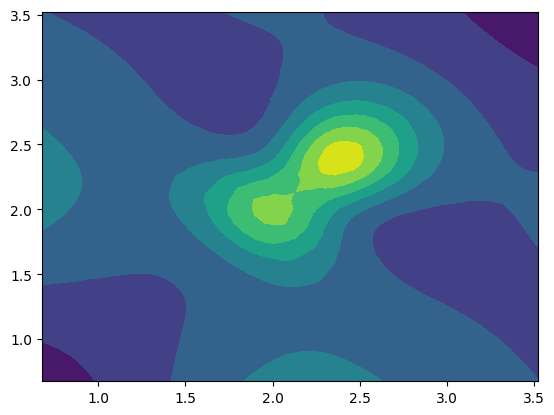

In [2]:
import matplotlib.pyplot as plt
xx = grid_points[:,0]
yy = grid_points[:,1]
zz = grid_points[:,2]
ww = w_regular_flat
print(np.min(ww),np.max(ww))
print(len(zz),np.max(zz))
z_min = yy[int(len(yy)/2)]
print(z_min)
plt.tricontourf(xx[yy==z_min],zz[yy==z_min],ww[yy==z_min])

In [13]:
from mayavi import mlab
W = w_regular.reshape(grid_size, grid_size, grid_size)

# ============================================
# MAYAVI ISOSURFACE
# ============================================

# Choose isosurface value (e.g., 50% of max value)
isovalue = 0.012

# Create the figure
fig = mlab.figure(size=(800, 800), bgcolor=(1, 1, 1))  # White background

# Plot isosurface
src = mlab.pipeline.scalar_field(X, Y, Z, W)
mlab.pipeline.iso_surface(src, contours=[isovalue], opacity=0.8, color=(0.2, 0.4, 0.8))

# Add axes and labels
mlab.axes(xlabel='X', ylabel='Y', zlabel='Z', color=(0, 0, 0))
mlab.outline(color=(0, 0, 0))

# Add colorbar
mlab.colorbar(title='Value', orientation='vertical')

# Set view
mlab.view(azimuth=45, elevation=45, distance='auto')

# Show the plot
mlab.show()